# Feature Encoding Extended Analysis

This notebook cleans the raw CMsiRNAdb dataset with `MoreStrictDataCleaner`, encodes the experimental features with `FeatureEncoderExtended`, and visualizes the distribution of the encoded columns.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.data_cleaning_more_strict import MoreStrictDataCleaner
from utils.feature_encoding_extended import FeatureEncoderExtended

sns.set_theme(style="whitegrid")

In [2]:
raw_data_path_env = os.environ.get("CMSIRNA_RAW_DATA_PATH")
processed_dir_env = os.environ.get("CMSIRNA_PROCESSED_DIR")

if not raw_data_path_env:
    raise ValueError("Set CMSIRNA_RAW_DATA_PATH in your local .envrc before running this notebook.")
if not processed_dir_env:
    raise ValueError("Set CMSIRNA_PROCESSED_DIR in your local .envrc before running this notebook.")

data_path = Path(raw_data_path_env).expanduser()
processed_dir = Path(processed_dir_env).expanduser()

df_raw = pd.read_csv(data_path, sep="\t", low_memory=False)
df_clean = MoreStrictDataCleaner(df_raw.copy()).clean()
encoder = FeatureEncoderExtended(df_clean)
df_encoded = encoder.encode()
encoded_feature_table = encoder.experimental_feature_table()

print("Raw shape:", df_raw.shape)
print("Cleaned shape:", df_clean.shape)
print("Encoded shape:", df_encoded.shape)


dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Raw shape: (43153, 26)
Cleaned shape: (33450, 20)
Encoded shape: (33450, 44)


/Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/utils/data_cleaning_more_strict.py:48: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.file["Time_of_administration"] = parsed.where(parsed.notna(), self.file["Time_of_administration"])


In [3]:
display(encoded_feature_table.head())

encoded_columns = [
    "Concentration_nM",
    "Concentration_log10_nM",
    "Concentration_zscore",
    "Time_hours",
    "Time_zscore",
    "Time_bin",
    "has_sd",
] + encoder.cell_type_columns

print("Number of encoded columns:", len(encoded_columns))
display(pd.Series(encoded_columns, name="encoded_column"))

,ID,Target_Gene,Inhibition,Cell_Type,Concentration,Concentration_nM,Concentration_log10_nM,Concentration_zscore,Time_of_administration,Time_hours,...,cell_Huh7,cell_Human iPSC-derived cortical neurons,cell_Human neuroblastoma Kelly cells(DSMZ),cell_Neuro2A cell line,cell_Non-human hepatocytes,cell_Primary Cynomolgus Monkey Hepatocytes,cell_Primary Macaque Hepatocytes,cell_Primary human hepatocytes,cell_Primary mouse hepatocytes,cell_RT-4
0,001-01-01-00001-100n-48h-88.00,CTNNB1,88.0,Hela,100.0,100.0,2.0,1.576543,48,48,...,0,0,0,0,0,0,0,0,0,0
1,001-01-01-00002-100n-48h-90.00,CTNNB1,90.0,Hela,100.0,100.0,2.0,1.576543,48,48,...,0,0,0,0,0,0,0,0,0,0
2,001-01-01-00003-100n-48h-90.00,CTNNB1,90.0,Hela,100.0,100.0,2.0,1.576543,48,48,...,0,0,0,0,0,0,0,0,0,0
3,001-01-01-00004-100n-48h-89.00,CTNNB1,89.0,Hela,100.0,100.0,2.0,1.576543,48,48,...,0,0,0,0,0,0,0,0,0,0
4,001-01-01-00005-100n-48h-87.00,CTNNB1,87.0,Hela,100.0,100.0,2.0,1.576543,48,48,...,0,0,0,0,0,0,0,0,0,0


Number of encoded columns: 24


0                               Concentration_nM
1                         Concentration_log10_nM
2                           Concentration_zscore
3                                     Time_hours
4                                    Time_zscore
5                                       Time_bin
6                                         has_sd
7                          cell_Be(2)C cell line
8                                      cell_COS7
9                                   cell_HEK293A
10                                     cell_Hela
11                                    cell_Hep3B
12                                    cell_HepG2
13                                  cell_Hepa1-6
14                                     cell_Huh7
15      cell_Human iPSC-derived cortical neurons
16    cell_Human neuroblastoma Kelly cells(DSMZ)
17                        cell_Neuro2A cell line
18                    cell_Non-human hepatocytes
19    cell_Primary Cynomolgus Monkey Hepatocytes
20              cell

## 1. Missingness And Summary

In [11]:
encoded_missing_summary = pd.DataFrame({
    "missing_count": df_encoded[encoded_columns].isna().sum(),
    "missing_percent": (df_encoded[encoded_columns].isna().mean() * 100).round(2),
})
display(encoded_missing_summary)

numeric_encoded_columns = [
    "Concentration_nM",
    "Concentration_log10_nM",
    "Concentration_zscore",
    "Time_hours",
    "Time_zscore",
]
display(df_encoded[numeric_encoded_columns].describe())

,missing_count,missing_percent
Concentration_nM,0,0.0
Concentration_log10_nM,0,0.0
Concentration_zscore,0,0.0
Time_hours,0,0.0
Time_zscore,0,0.0
Time_bin,0,0.0
has_sd,0,0.0
cell_Be(2)C cell line,0,0.0
cell_COS7,0,0.0
cell_HEK293A,0,0.0


,Concentration_nM,Concentration_log10_nM,Concentration_zscore,Time_hours,Time_zscore
count,33450.000000,33450.000000,3.345000e+04,33450.000000,3.345000e+04
mean,13.620258,0.278719,-4.418323e-17,32.014111,1.597394e-16
std,25.099847,1.091808,1.000000e+00,18.349898,1.000000e+00
min,0.000170,-3.769551,-3.707860e+00,24.000000,-4.367387e-01
25%,0.100000,-1.000000,-1.171194e+00,24.000000,-4.367387e-01
50%,1.000000,0.000000,-2.552818e-01,24.000000,-4.367387e-01
75%,10.000000,1.000000,6.606305e-01,24.000000,-4.367387e-01
max,200.000000,2.301030,1.852260e+00,168.000000,7.410716e+00


## 2. Concentration Encodings

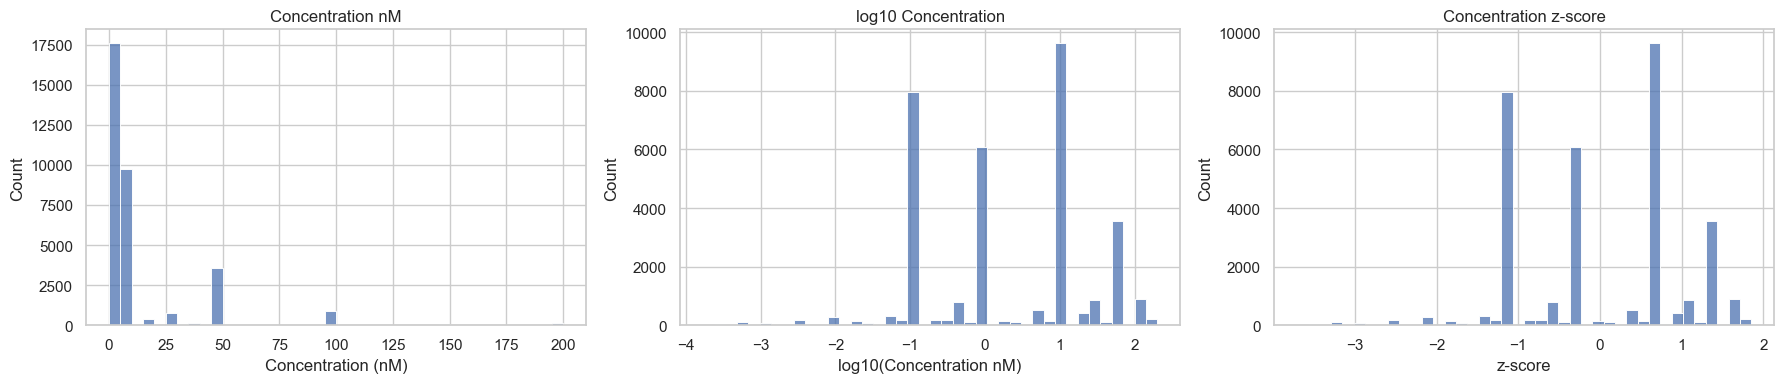

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df_encoded["Concentration_nM"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Concentration nM")
axes[0].set_xlabel("Concentration (nM)")

sns.histplot(df_encoded["Concentration_log10_nM"].dropna(), bins=40, ax=axes[1])
axes[1].set_title("log10 Concentration")
axes[1].set_xlabel("log10(Concentration nM)")

sns.histplot(df_encoded["Concentration_zscore"].dropna(), bins=40, ax=axes[2])
axes[2].set_title("Concentration z-score")
axes[2].set_xlabel("z-score")

plt.tight_layout()
plt.show()

## 3. Time Encodings

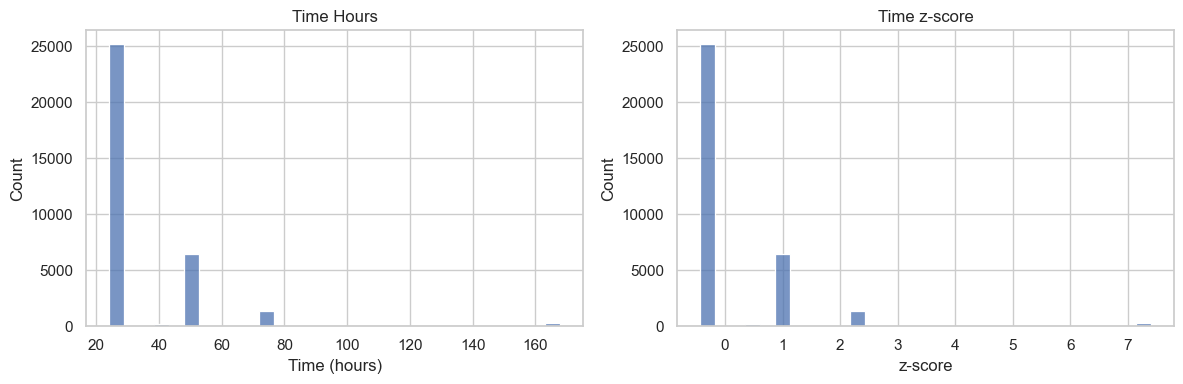

,Time_bin,count
0,<=24h,25153
1,24-48h,6614
2,>48h,1683


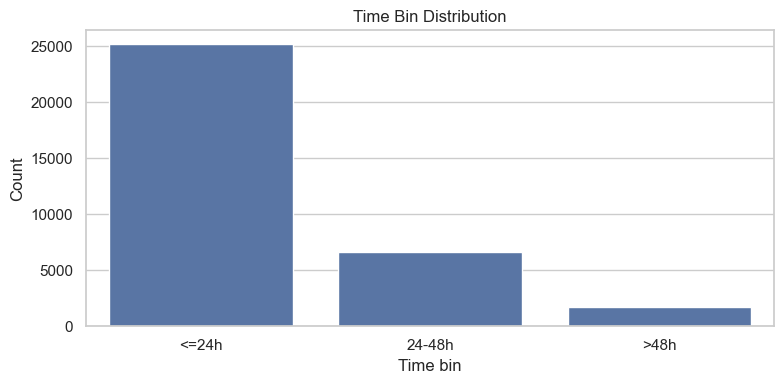

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_encoded["Time_hours"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Time Hours")
axes[0].set_xlabel("Time (hours)")

sns.histplot(df_encoded["Time_zscore"].dropna(), bins=30, ax=axes[1])
axes[1].set_title("Time z-score")
axes[1].set_xlabel("z-score")

plt.tight_layout()
plt.show()

time_bin_counts = df_encoded["Time_bin"].value_counts(dropna=False).rename_axis("Time_bin").reset_index(name="count")
display(time_bin_counts)

time_bin_counts_plot = time_bin_counts.copy()
time_bin_counts_plot["Time_bin"] = time_bin_counts_plot["Time_bin"].astype(str)
plt.figure(figsize=(8, 4))
sns.barplot(data=time_bin_counts_plot, x="Time_bin", y="count")
plt.title("Time Bin Distribution")
plt.xlabel("Time bin")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 4. SD Availability Encoding

,has_sd,count
0,0,19118
1,1,14332


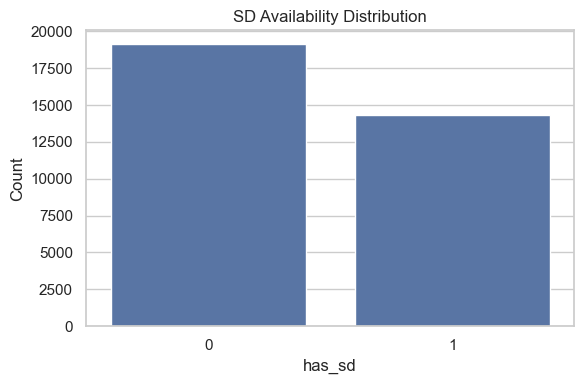

In [7]:
has_sd_counts = df_encoded["has_sd"].value_counts(dropna=False).rename_axis("has_sd").reset_index(name="count")
display(has_sd_counts)

plt.figure(figsize=(6, 4))
sns.barplot(data=has_sd_counts, x="has_sd", y="count")
plt.title("SD Availability Distribution")
plt.xlabel("has_sd")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 5. Cell Type One-Hot Encodings

,cell_one_hot_column,count
0,cell_Hep3B,12165
1,cell_Primary Cynomolgus Monkey Hepatocytes,4445
2,cell_COS7,3888
3,cell_Primary human hepatocytes,3015
4,cell_Hela,2005
5,cell_Be(2)C cell line,1966
6,cell_HepG2,1651
7,cell_Huh7,1602
8,cell_HEK293A,1048
9,cell_Primary mouse hepatocytes,501


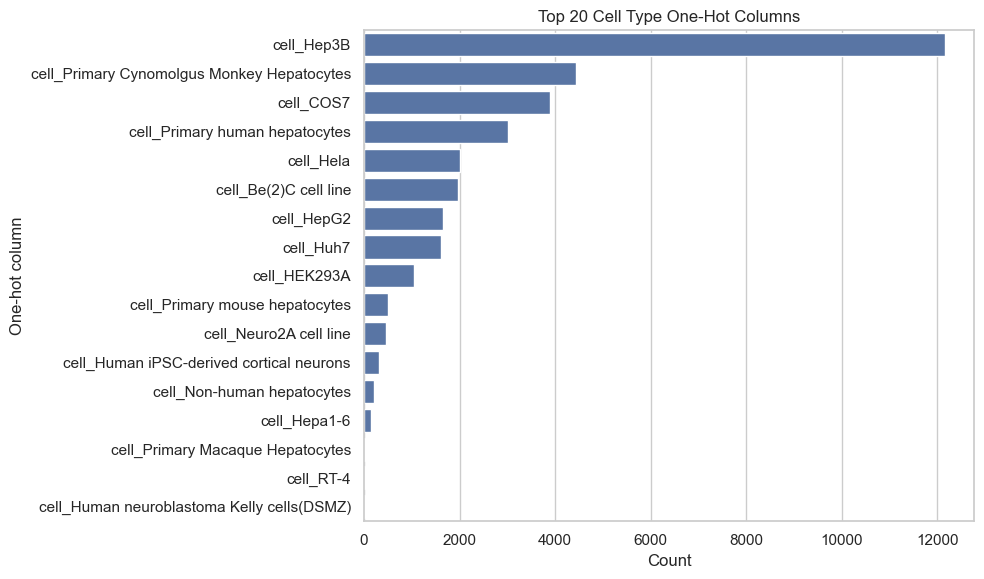

In [8]:
cell_type_one_hot_counts = df_encoded[encoder.cell_type_columns].sum().sort_values(ascending=False).rename("count").reset_index()
cell_type_one_hot_counts = cell_type_one_hot_counts.rename(columns={"index": "cell_one_hot_column"})
display(cell_type_one_hot_counts)

plt.figure(figsize=(10, max(4, len(cell_type_one_hot_counts.head(20)) * 0.35)))
sns.barplot(data=cell_type_one_hot_counts.head(20), y="cell_one_hot_column", x="count")
plt.title("Top 20 Cell Type One-Hot Columns")
plt.xlabel("Count")
plt.ylabel("One-hot column")
plt.tight_layout()
plt.show()

## 6. Encoded Column Correlations

,Concentration_nM,Concentration_log10_nM,Concentration_zscore,Time_hours,Time_zscore,has_sd
Concentration_nM,1.000000,0.655873,0.655873,0.346140,0.346140,0.005217
Concentration_log10_nM,0.655873,1.000000,1.000000,0.172082,0.172082,0.037745
Concentration_zscore,0.655873,1.000000,1.000000,0.172082,0.172082,0.037745
Time_hours,0.346140,0.172082,0.172082,1.000000,1.000000,-0.131304
Time_zscore,0.346140,0.172082,0.172082,1.000000,1.000000,-0.131304
has_sd,0.005217,0.037745,0.037745,-0.131304,-0.131304,1.000000


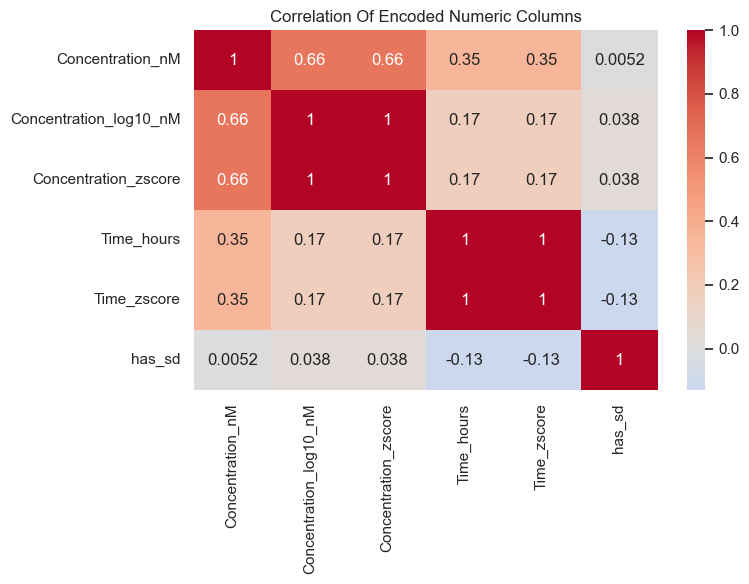

In [9]:
corr_columns = [
    "Concentration_nM",
    "Concentration_log10_nM",
    "Concentration_zscore",
    "Time_hours",
    "Time_zscore",
    "has_sd",
]
corr_df = df_encoded[corr_columns].corr(numeric_only=True)
display(corr_df)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Of Encoded Numeric Columns")
plt.tight_layout()
plt.show()

## 7. Save Outputs

In [10]:
processed_dir.mkdir(parents=True, exist_ok=True)
encoded_feature_table.to_csv(processed_dir / "CMsiRNA_feature_encoding_extended.tsv", sep="\t", index=False)
df_encoded.to_csv(processed_dir / "CMsiRNA_feature_encoding_extended_full.tsv", sep="\t", index=False)
print("Saved outputs to:", processed_dir)

Saved outputs to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
